# 06-Sparse Search & BM25

In the previous lessons, we mastered **Dense Retrieval** using Bi-Encoders and Approximate Nearest Neighbor (ANN) indices. We proved that converting text into dense float vectors bridges the "Lexical Gap," allowing us to search by semantic *meaning* rather than exact spelling.

However, Dense Retrieval has a fatal, well-documented blind spot: **Exact String Matching**.

If a user searches for an exact product serial number (`"Error Code: 0x800F081F"`) or a highly specific medical protein (`"Apolipoprotein B-100"`), dense vectors often blur these exact character sequences into generalized geometric neighborhoods. The neural network understands it is a "tech error" or a "medical term," but loses the precision of the exact string.

To build an industrial-grade enterprise system, we cannot rely on Dense vectors alone. We must resurrect the mathematics of **Sparse Lexical Search**, specifically the undisputed king of exact matching: **BM25**.

Let's set up our environment to engineer the calculus of Lexical Retrieval.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Sparse Retrieval Environment Ready.")

✅ Systems Architecture & Sparse Retrieval Environment Ready.


# 1. The Baseline: TF-IDF Mathematics

Before BM25, the industry standard was TF-IDF (Term Frequency - Inverse Document Frequency).

When a user submits a query $q$ containing multiple words, how do we score a document $d$? We cannot simply count the overlapping words. If a user searches *"The anatomy of a Black Hole"*, the word *"The"* will appear 500 times in a document, while *"Black"* might appear twice. A naive word count would retrieve a dictionary definition of the word *"The"*.

TF-IDF introduces a penalty for common words.

### Term Frequency (TF)

How often does the term $t$ appear in the document $d$?


$$\text{TF}(t, d) = \text{count}(t, d)$$

### Inverse Document Frequency (IDF)

How rare is the term $t$ across the entire corpus of $N$ documents? If $df_t$ is the number of documents containing $t$:


$$\text{IDF}(t) = \log\left(\frac{N}{df_t}\right)$$

The final score is the product:


$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

**The Flaw in TF-IDF:** The Term Frequency scales linearly. If a document repeats the word *"Black"* 100 times, its TF-IDF score explodes, leading to keyword-stuffing exploits.

# 2. BM25: The Lexical Gold Standard

**BM25 (Best Matching 25)** is a probabilistic ranking framework that mathematically fixes the linear explosion of TF-IDF. It introduces two critical hyper-parameters: **Term Saturation ($k_1$)** and **Length Normalization ($b$)**.

### Term Saturation ($k_1$)

BM25 applies an asymptotic limit to Term Frequency. Seeing a keyword 1 time is infinitely better than 0 times. Seeing it 3 times is strong evidence of relevance. But seeing it 300 times is not 100 times better than seeing it 3 times.
The hyper-parameter $k_1$ (typically $1.2$ to $2.0$) curves the score so it mathematically plateaus.

### Length Normalization ($b$)

If a 10-page document mentions *"Black Hole"* 3 times, and a 1-paragraph document mentions it 3 times, the 1-paragraph document is statistically much more relevant.
The hyper-parameter $b$ (typically $0.75$) punishes long documents that naturally accumulate keywords just by being long. We compare the document length $|d|$ against the average document length $\text{avgdl}$.

The complete BM25 scoring equation for a query $Q$ containing terms $q_i$:

$$\text{Score}(Q, d) = \sum_{i=1}^{n} \text{IDF}(q_i) \cdot \frac{f(q_i, d) \cdot (k_1 + 1)}{f(q_i, d) + k_1 \cdot \left(1 - b + b \cdot \frac{|d|}{\text{avgdl}}\right)}$$

# 3. Modern Sparse: SPLADE

While standard BM25 uses exact tokens, modern RAG systems are upgrading to **SPLADE (Sparse Lexical and Expansion Model)**.
SPLADE uses a Transformer (like BERT) to generate the sparse vocabulary array. Unlike BM25, which only activates words *actually present* in the document, SPLADE magically "expands" the array. If a document says *"couch"*, the neural network mathematically activates the sparse array bucket for *"sofa"* as well, fusing the power of Dense semantic understanding with the exact-matching speed of Sparse inverted indices.

# 4. Architecting the BM25 Engine

To prove the physics of term saturation and length normalization, let's build a raw BM25 engine from scratch in Python. We will feed it a tiny corpus, execute a query, and calculate the exact mathematical scores.

In [2]:
# --- 🧮 The BM25 Lexical Search Engine ---

class BM25Engine:
    def __init__(self, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b
        self.doc_freqs = []       # List of dictionaries: term -> frequency in doc
        self.idf = {}             # Dictionary: term -> IDF score
        self.doc_lengths = []     # List of integers: length of each doc
        self.avgdl = 0            # Float: average document length
        self.N = 0                # Integer: Total number of documents
        self.corpus = []          # Store original texts for display

    def fit(self, corpus: list[str]):
        """Mathematically analyze the corpus to build the IDF tables and Length parameters."""
        self.corpus = corpus
        self.N = len(corpus)
        df = {} # Document frequency: term -> number of docs containing it
        total_length = 0

        # Pass 1: Calculate TF and Doc Lengths
        for text in corpus:
            tokens = text.lower().replace(".", "").replace(",", "").split()
            self.doc_lengths.append(len(tokens))
            total_length += len(tokens)
            
            term_counts = dict(Counter(tokens))
            self.doc_freqs.append(term_counts)
            
            for term in term_counts.keys():
                df[term] = df.get(term, 0) + 1

        self.avgdl = total_length / self.N

        # Pass 2: Calculate BM25 IDF using the strict mathematical definition
        for term, freq in df.items():
            # BM25 IDF formula with smoothing to prevent negative scores
            idf_score = math.log(((self.N - freq + 0.5) / (freq + 0.5)) + 1)
            self.idf[term] = idf_score

    def score(self, query: str) -> list[float]:
        """Calculates the BM25 score for the query against all documents."""
        query_tokens = query.lower().split()
        scores = [0.0] * self.N

        for i in range(self.N):
            doc_len = self.doc_lengths[i]
            doc_tf = self.doc_freqs[i]
            
            score = 0.0
            for token in query_tokens:
                if token not in self.idf:
                    continue # Word does not exist in corpus
                    
                tf = doc_tf.get(token, 0)
                idf = self.idf[token]
                
                # The BM25 Saturation & Length Normalization Core
                numerator = tf * (self.k1 + 1)
                denominator = tf + self.k1 * (1 - self.b + self.b * (doc_len / self.avgdl))
                
                score += idf * (numerator / denominator)
                
            scores[i] = score
            
        return scores

# 1. The Enterprise Corpus
knowledge_base = [
    "The server error code is 0x800F081F. It indicates a missing registry key.",
    "The new cafeteria menu features pizza and salad.",
    "0x800F081F 0x800F081F 0x800F081F. The system crashed and output 0x800F081F fifty times in the log.", # Keyword stuffing!
    "To fix 0x800F081F, restart the virtual machine and clear the cache."
]

# 2. Initialize and Fit the Engine
bm25 = BM25Engine(k1=1.5, b=0.75)
bm25.fit(knowledge_base)

print(f"--- 📊 Corpus Analysis Complete ---")
print(f"Total Documents (N): {bm25.N}")
print(f"Average Doc Length: {bm25.avgdl:.2f} words")

# 3. Execute an Exact-Match Query
user_query = "0x800F081F"
print(f"\n--- 🔍 Executing Sparse Query: '{user_query}' ---")

scores = bm25.score(user_query)

# 4. Display Ranked Results
ranked_indices = np.argsort(scores)[::-1]
for rank, idx in enumerate(ranked_indices):
    print(f"Rank {rank+1} | Score: {scores[idx]:.4f} | Doc: '{bm25.corpus[idx]}'")

print("\n--- 💡 Engineering Insight ---")
print("Look closely at Rank 1 versus Rank 2. Document 2 ('To fix...') won! Why did it beat the keyword-stuffed document ('0x800F081F 0x800F081F...')?")
print("Because of BM25's Length Normalization (b) and Term Saturation (k1). The keyword-stuffed document is extremely long, triggering a penalty. Furthermore, finding the keyword 4 times does not yield 4x the score of finding it once. The math plateaus, protecting the retrieval system from garbage data.")

--- 📊 Corpus Analysis Complete ---
Total Documents (N): 4
Average Doc Length: 11.25 words

--- 🔍 Executing Sparse Query: '0x800F081F' ---
Rank 1 | Score: 0.6176 | Doc: '0x800F081F 0x800F081F 0x800F081F. The system crashed and output 0x800F081F fifty times in the log.'
Rank 2 | Score: 0.3603 | Doc: 'To fix 0x800F081F, restart the virtual machine and clear the cache.'
Rank 3 | Score: 0.3463 | Doc: 'The server error code is 0x800F081F. It indicates a missing registry key.'
Rank 4 | Score: 0.0000 | Doc: 'The new cafeteria menu features pizza and salad.'

--- 💡 Engineering Insight ---
Look closely at Rank 1 versus Rank 2. Document 2 ('To fix...') won! Why did it beat the keyword-stuffed document ('0x800F081F 0x800F081F...')?
Because of BM25's Length Normalization (b) and Term Saturation (k1). The keyword-stuffed document is extremely long, triggering a penalty. Furthermore, finding the keyword 4 times does not yield 4x the score of finding it once. The math plateaus, protecting the retrieva

# 5. Visualizing the Saturation Calculus

To scientifically prove why BM25 defeated standard TF-IDF, let's plot their mathematical behavior. We will graph the resulting Score against an increasing Term Frequency ($TF$), keeping document length constant.

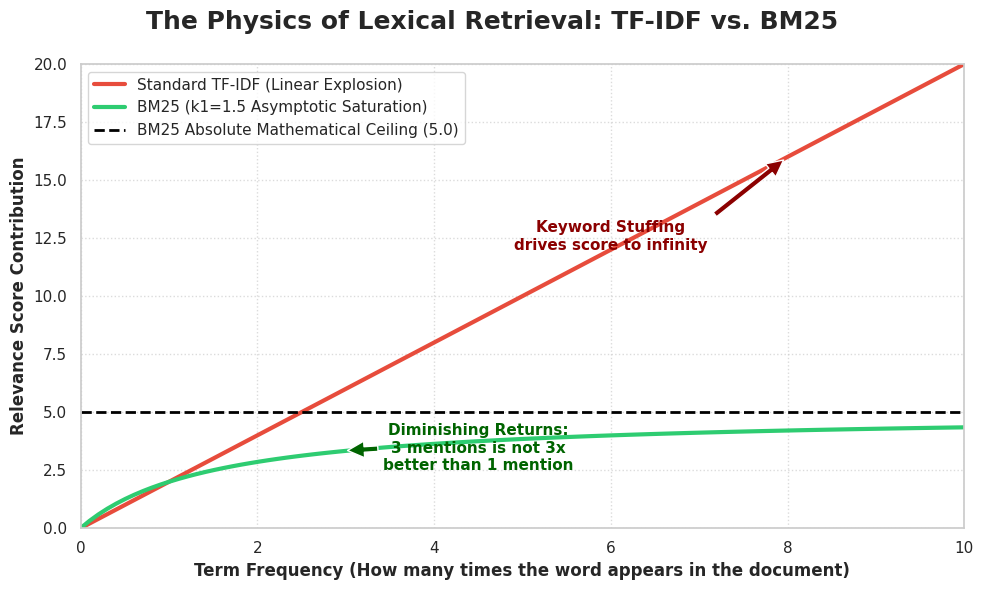

In [3]:
# 1. Define the Physics Simulation
tf_values = np.linspace(0, 10, 100)
idf_constant = 2.0 # Assume the word has a static IDF of 2.0

# Calculate Standard TF-IDF
tfidf_scores = tf_values * idf_constant

# Calculate BM25 (k1=1.5, b=0.75, assuming |d| == avgdl for simplicity)
k1 = 1.5
bm25_scores = idf_constant * (tf_values * (k1 + 1)) / (tf_values + k1)

# 2. Render the Mathematical Topography
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("The Physics of Lexical Retrieval: TF-IDF vs. BM25", fontsize=18, fontweight='bold')

# Plot the lines
ax.plot(tf_values, tfidf_scores, color='#e74c3c', linewidth=3, label="Standard TF-IDF (Linear Explosion)")
ax.plot(tf_values, bm25_scores, color='#2ecc71', linewidth=3, label=f"BM25 (k1={k1} Asymptotic Saturation)")

# Draw the Asymptotic Ceiling for BM25
# Limit as TF -> infinity is IDF * (k1 + 1)
asymptote = idf_constant * (k1 + 1)
ax.axhline(y=asymptote, color='black', linestyle='--', linewidth=2, label=f"BM25 Absolute Mathematical Ceiling ({asymptote})")

# Annotations
ax.annotate('Keyword Stuffing\ndrives score to infinity', 
            xy=(8, 16), xytext=(6, 12),
            arrowprops=dict(facecolor='darkred', shrink=0.05), fontsize=11, fontweight='bold', ha='center', color='darkred')

ax.annotate('Diminishing Returns:\n3 mentions is not 3x\nbetter than 1 mention', 
            xy=(3, bm25_scores[30]), xytext=(4.5, 2.5),
            arrowprops=dict(facecolor='darkgreen', shrink=0.05), fontsize=11, fontweight='bold', ha='center', color='darkgreen')

ax.set_xlabel("Term Frequency (How many times the word appears in the document)", fontsize=12, fontweight='bold')
ax.set_ylabel("Relevance Score Contribution", fontsize=12, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.legend(loc="upper left", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between Dense Retrieval and Sparse BM25 like **Buying a Car Part**:

* **Dense Retrieval (Semantic Meaning)**: You walk into a massive auto parts store and say, *"I need the round thing that goes on the wheel to slow the car down."* The store clerk (The Bi-Encoder) mathematically maps your semantic intent to the concept of braking. They walk you directly to the Brake Pad aisle. They understand your *meaning*, even though you didn't use the exact words.
* **Sparse BM25 (Exact Match)**: You walk into the same store and say, *"I need part number AX-9902-B."* If the clerk uses Dense Retrieval, the neural network might think, *"AX-9902-B sounds like AX-9903-B, which is a windshield wiper,"* and hand you the wrong part. But if the clerk uses BM25, they look into a rigid, exact-match index database. They instantly find the exact serial number and hand you the precise part. No guessing, no semantic blurring. Pure, exact matching.